In [ ]:
import sys, pathlib
root = pathlib.Path.cwd()
if not (root / "src").is_dir():          # walk up until we find src/
    root = next(p for p in root.parents if (p / "src").is_dir())
sys.path.insert(0, str(root))

from src import read_hobo_log, read_vusitu_log, clean_hobo_log, clean_vusitu_log

In [29]:
header_abs, data_abs, units_abs = read_vusitu_log(r"C:\Users\whe255\dev\stage_discharge\imports\tests\VuSitu_Log_2025-10-15_18-00-00_dolan_xing_tube_20251015_dolanXing.csv")
data_abs = clean_vusitu_log(data_abs)
print(data_abs.head())

header_baro, data_baro, units_baro = read_vusitu_log(r"C:\Users\whe255\dev\stage_discharge\imports\tests\VuSitu_Log_2025-10-15_18-00-00_Dolan_Baro_20251015_DolanBaro.csv")
data_baro = clean_vusitu_log(data_baro)
print(data_baro.head())

data, units = read_hobo_log(r"C:\Users\whe255\dev\stage_discharge\imports\tests\DEV300_20260914_export3-2026_09_14_14_16_02_UTC.csv")
data = clean_hobo_log(data)
print(data.head())

                         temperature_c  pressure_psi
datetime                                            
2025-10-15 18:00:00.056      25.595337     14.526523
2025-10-15 18:15:00.056      25.595337     14.523331
2025-10-15 18:30:00.056      25.496368     14.518873
2025-10-15 18:45:00.056      25.446854     14.523428
2025-10-15 19:00:00.056      25.347809     14.521363
                         temperature_c  pressure_psi
datetime                                            
2025-10-15 18:00:00.057      28.177536     13.988504
2025-10-15 18:15:00.057      28.029724     13.996856
2025-10-15 18:30:00.057      27.881851     13.994680
2025-10-15 18:45:00.057      27.783234     13.993465
2025-10-15 19:00:00.057      27.684555     13.995752
                           diff_pressure_psi  absolute_pressure_psi  \
datetime                                                              
2026-04-22 16:15:00+00:00                NaN                    NaN   
2026-04-22 16:20:00+00:00                NaN 

In [35]:
data_abs.index

DatetimeIndex(['2025-10-15 18:00:00.056000', '2025-10-15 18:15:00.056000',
               '2025-10-15 18:30:00.056000', '2025-10-15 18:45:00.056000',
               '2025-10-15 19:00:00.056000', '2025-10-15 19:15:00.056000',
               '2025-10-15 19:30:00.056000', '2025-10-15 19:45:00.056000',
               '2025-10-15 20:00:00.056000', '2025-10-15 20:15:00.056000',
               ...
               '2026-05-01 12:30:00.056000', '2026-05-01 12:45:00.056000',
               '2026-05-01 13:00:00.056000', '2026-05-01 13:15:00.056000',
               '2026-05-01 13:30:00.056000', '2026-05-01 13:45:00.056000',
               '2026-05-01 14:00:00.056000', '2026-05-01 14:15:00.056000',
               '2026-05-01 14:30:00.056000', '2026-05-01 14:45:00.056000'],
              dtype='datetime64[us]', name='datetime', length=18996, freq=None)

In [37]:
import pandas as pd

vudolan = pd.merge_asof(
    data_abs.sort_index(), data_baro.sort_index(),
    left_index=True, right_index=True,
    direction="nearest",
    tolerance=pd.Timedelta("1s"),      # pair a reading only with a baro sample within 1 s
    suffixes=("_abs", "_baro"),
)

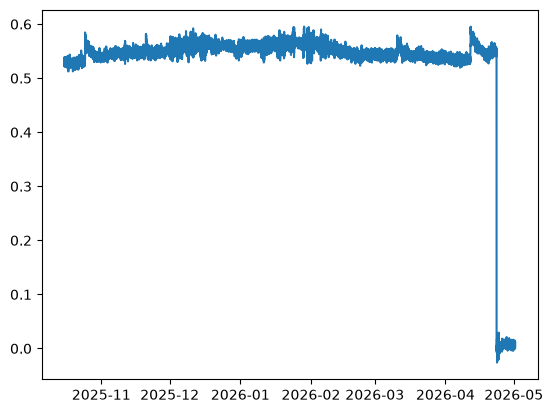

In [40]:
vudolan['diff'] = vudolan.pressure_psi_abs - vudolan.pressure_psi_baro
plt.plot(vudolan['diff'])